In [1]:
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.constants as const
from astropy.utils.data import download_file

In [2]:
%matplotlib ipympl

In [13]:
meta_tab = Table.read(download_file("https://zenodo.org/records/2539456/files/plasticc_test_metadata.csv.gz", cache=True), format='ascii.csv')
data_tab = Table.read(download_file("https://zenodo.org/records/2539456/files/plasticc_test_lightcurves_01.csv.gz", cache=True), format='ascii.csv')

In [14]:
tde_meta_tab = meta_tab[meta_tab['true_target'] == 15]
tde_meta_tab

object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,true_target,true_submodel,true_z,true_distmod,true_lensdmu,true_vpec,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
int64,float64,float64,int64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
9197,2.0711,-45.1916,1,-9.0,1.357,0.224,44.921,0.011,0,15,1,1.085,44.321,0.02,416.0,3.1,0.043,60235.117,70,0.0,0.0,0.0,0.0,0.0,0.0
13371,34.8047,-5.8292,1,-9.0,1.265,0.054,44.732,0.023,0,15,1,1.176,44.539,0.015,234.9,3.1,0.092,59743.074,97,0.0,0.0,0.0,0.0,0.0,0.0
27066,52.207,-28.2916,1,0.621,0.614,0.008,42.8,0.007,0,15,1,0.62,42.828,0.016,-13.9,3.1,0.169,60245.172,87,0.0,0.0,0.0,0.0,0.0,0.0
27885,149.4141,3.4338,1,0.375,0.497,0.255,42.248,0.027,0,15,1,0.377,41.531,-0.014,-271.5,3.1,0.896,59929.977,107,0.0,0.0,0.0,0.0,0.0,0.0
39688,33.75,-4.6305,1,0.208,0.211,0.009,40.091,0.019,0,15,1,0.21,40.071,-0.009,-707.4,3.1,1.61,59840.355,28,0.0,0.0,0.0,0.0,0.0,0.0
40473,352.3987,-62.6967,1,0.524,0.547,0.011,42.495,0.02,0,15,1,0.523,42.378,-0.022,283.2,3.1,0.193,60241.063,131,0.0,0.0,0.0,0.0,0.0,0.0
47387,33.5742,-6.5796,1,-9.0,0.966,0.269,44.006,0.021,0,15,1,1.53,45.243,0.029,-559.1,3.1,0.346,60262.324,9,0.0,0.0,0.0,0.0,0.0,0.0
52901,52.5586,-27.2796,1,-9.0,0.85,0.026,43.665,0.008,0,15,1,0.798,43.497,0.018,184.0,3.1,0.588,60614.578,53,0.0,0.0,0.0,0.0,0.0,0.0
54590,359.8163,-44.0031,1,-9.0,0.614,0.014,42.801,0.013,0,15,1,0.625,42.847,0.014,-112.3,3.1,0.217,60598.07,82,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
obj_mask = np.in1d(data_tab['object_id'], tde_meta_tab['object_id'])

tde_tab = data_tab[obj_mask]
passband_lookup = {0: 'u', 1: 'g', 2: 'r', 3: 'i', 4: 'z', 5: 'y'}

tde_tab['passband'] = [passband_lookup[x] for x in tde_tab['passband']]
tde_tab['distmod'] = [tde_meta_tab[tde_meta_tab['object_id'] == x]['true_distmod'][0] for x in tde_tab['object_id']]

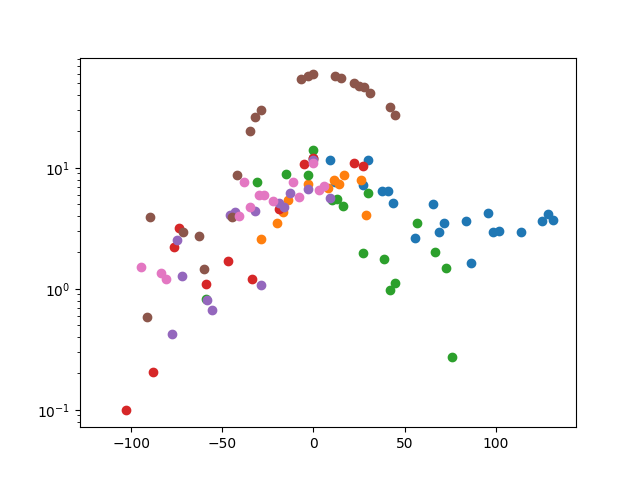

In [18]:
f, ax = plt.subplots()

ax.set_yscale('log')

for obj_id in list(set(tde_tab['object_id']))[:10]:
    sub_tab = tde_tab[(tde_tab['object_id'] == obj_id) & (tde_tab['passband'] == 'g')]

    if np.max(sub_tab['flux']) < 10 or len(sub_tab) < 20:
        continue

    sub_tab['mjd'] = sub_tab['mjd'] - sub_tab['mjd'][np.argmax(sub_tab['flux'])]
    sub_tab = sub_tab[(sub_tab['mjd'] > -200) & (sub_tab['mjd'] < 200)]

    ax.errorbar(sub_tab['mjd'], sub_tab['flux'],  marker='o', linestyle='')